# Loading data from kagglehub

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras

print(tf.__version__, keras.__version__)

I0000 00:00:1789609364.370808    5356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789609365.888955    5356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.21.0 3.15.1


In [2]:
# 6 GB of VRAM: without this TF grabs all of it at once, and a second notebook
# dies with an OOM that looks like a model problem but is not.
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
rng = np.random.default_rng(SEED)

In [5]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [6]:
import kagglehub

path = kagglehub.dataset_download('mohammadamireshraghi/blood-cell-cancer-all-4class')
path

/home/su_zal/Desktop/Linear Regression/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'/home/su_zal/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1'

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from pathlib import Path
from tensorflow.keras.preprocessing.image import load_img


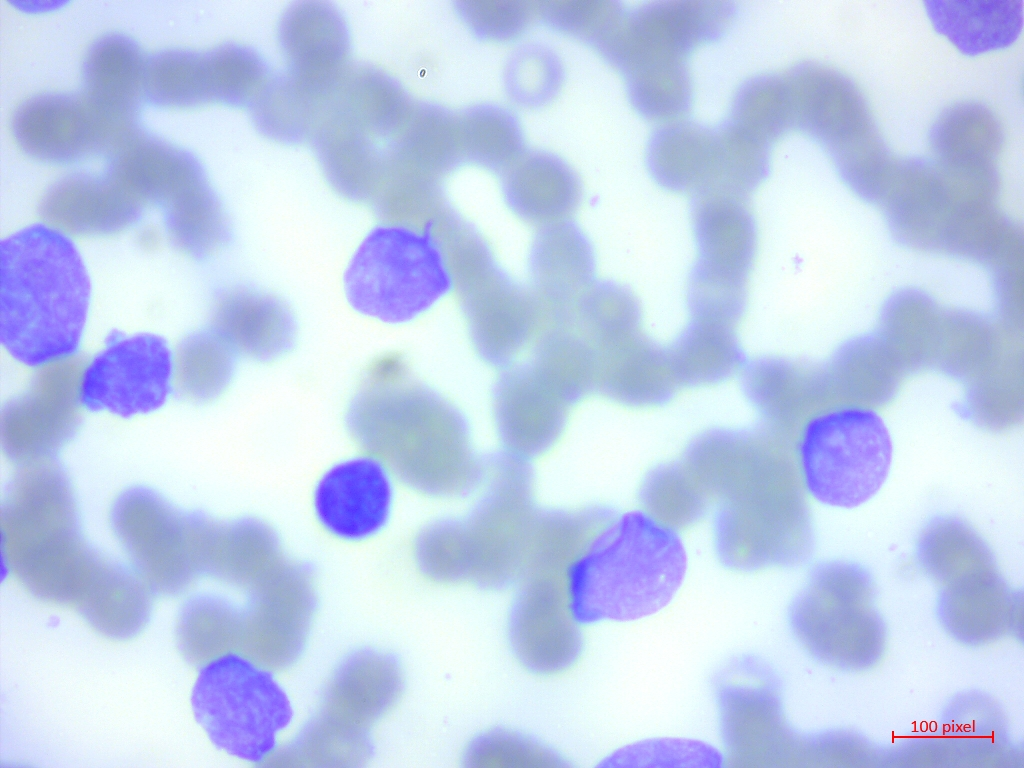

In [9]:
path = Path('/home/su_zal/Desktop/BLOODCELL_CANCER/Blood cell Cancer [ALL]/[Malignant] early Pre-B')
fullname = 'Sap_148 (8).jpg'

image = path / fullname
load_img(image)

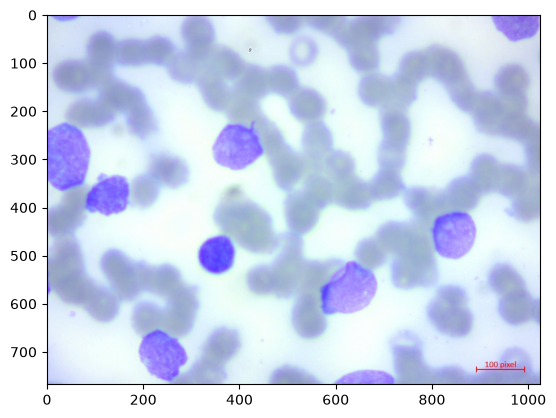

In [10]:
img = load_img(image)
plt.imshow(img)

In [11]:
x = np.array(img)
x.shape

(768, 1024, 3)

(299, 299, 3)

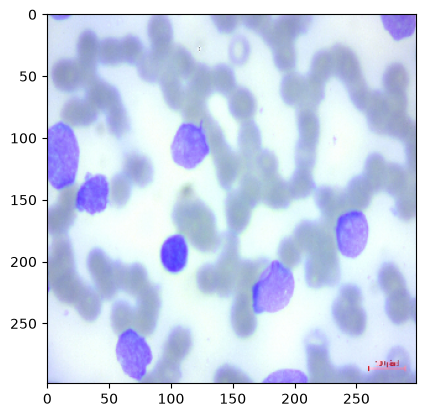

In [12]:
img = load_img(image, target_size=(299, 299))
plt.imshow(img)

x = np.array(img)
x.shape

# Pretrained CNN layers

In [6]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input    
from tensorflow.keras.applications.xception import decode_predictions

# model = Xception(weights='imagenet', input_shape=(299, 299, 3))

# X = np.array([x])
# X.shape

# X = preprocess_input(X)
# X.shape

# pred = model.predict(X)



In [14]:
decode_predictions(pred)

[[('n01910747', 'jellyfish', np.float32(0.6798487)),
  ('n03729826', 'matchstick', np.float32(0.015793031)),
  ('n09256479', 'coral_reef', np.float32(0.014916501)),
  ('n03888257', 'parachute', np.float32(0.013235377)),
  ('n07615774', 'ice_lolly', np.float32(0.013096167))]]

# PREPARING THE TRAIN TEST SPLIT

In [7]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# SEED comes from the setup cell at the top.
ROOT = Path('/home/su_zal/Desktop/BLOODCELL_CANCER/Blood cell Cancer [ALL]')

FOLDERS = ['Benign', '[Malignant] early Pre-B', '[Malignant] Pre-B', '[Malignant] Pro-B']
CLASSES = ['Benign', 'Early Pre-B', 'Pre-B', 'Pro-B']

# sorted() matters: the split below is only reproducible if the rows always
# come out in the same order.
rows = []
for folder, cls in zip(FOLDERS, CLASSES):
    for p in sorted((ROOT / folder).glob('*.jpg')):
        rows.append({'filename': str(p), 'label': cls})

df = pd.DataFrame(rows)
print(len(df), 'images')
df['label'].value_counts()[CLASSES]


3242 images


label
Benign         512
Early Pre-B    979
Pre-B          955
Pro-B          796
Name: count, dtype: int64

In [8]:
# stratify keeps each class at the same proportion in every split.
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'],
                                     random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.15,
                                    stratify=train_df['label'], random_state=SEED)

len(train_df), len(val_df), len(test_df)

(2341, 414, 487)

In [9]:
import cv2
from tqdm.auto import tqdm

data_dir = Path('./data/split')


def prepare(d, split):
    for cls in CLASSES:
        (data_dir / split / cls).mkdir(parents=True, exist_ok=True)

    for i, (f, cls) in enumerate(tqdm(list(zip(d['filename'], d['label'])),
                                      total=len(d), desc=split)):
        out = data_dir / split / cls / f'{i:05d}.jpg'
        if not out.exists():
            # INTER_AREA is the right filter for shrinking; INTER_LINEAR aliases.
            img = cv2.resize(cv2.imread(f), (299, 299), interpolation=cv2.INTER_AREA)
            cv2.imwrite(str(out), img)


prepare(train_df, 'train')
prepare(val_df, 'validation')
prepare(test_df, 'test')

for split in ['train', 'validation', 'test']:
    n = sum(1 for _ in (data_dir / split).rglob('*.jpg'))
    print(f'{split:<12} {n}')

/home/su_zal/Desktop/Linear Regression/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
test: 100%|██████████| 487/487 [00:00<00:00, 109307.33it/s]

train        2341
validation   414
test         487


# Transfer Learning

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [11]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

train_ds = train_gen.flow_from_directory(
    './data/split/train',
    target_size=(150, 150),
    batch_size=32
)

Found 2341 images belonging to 4 classes.


In [12]:
train_ds.class_indices

{'Benign': 0, 'Early Pre-B': 1, 'Pre-B': 2, 'Pro-B': 3}

In [15]:
X, y = next(train_ds)

In [22]:
y[:5]

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.]], dtype=float32)

In [13]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './data/split/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 414 images belonging to 4 classes.


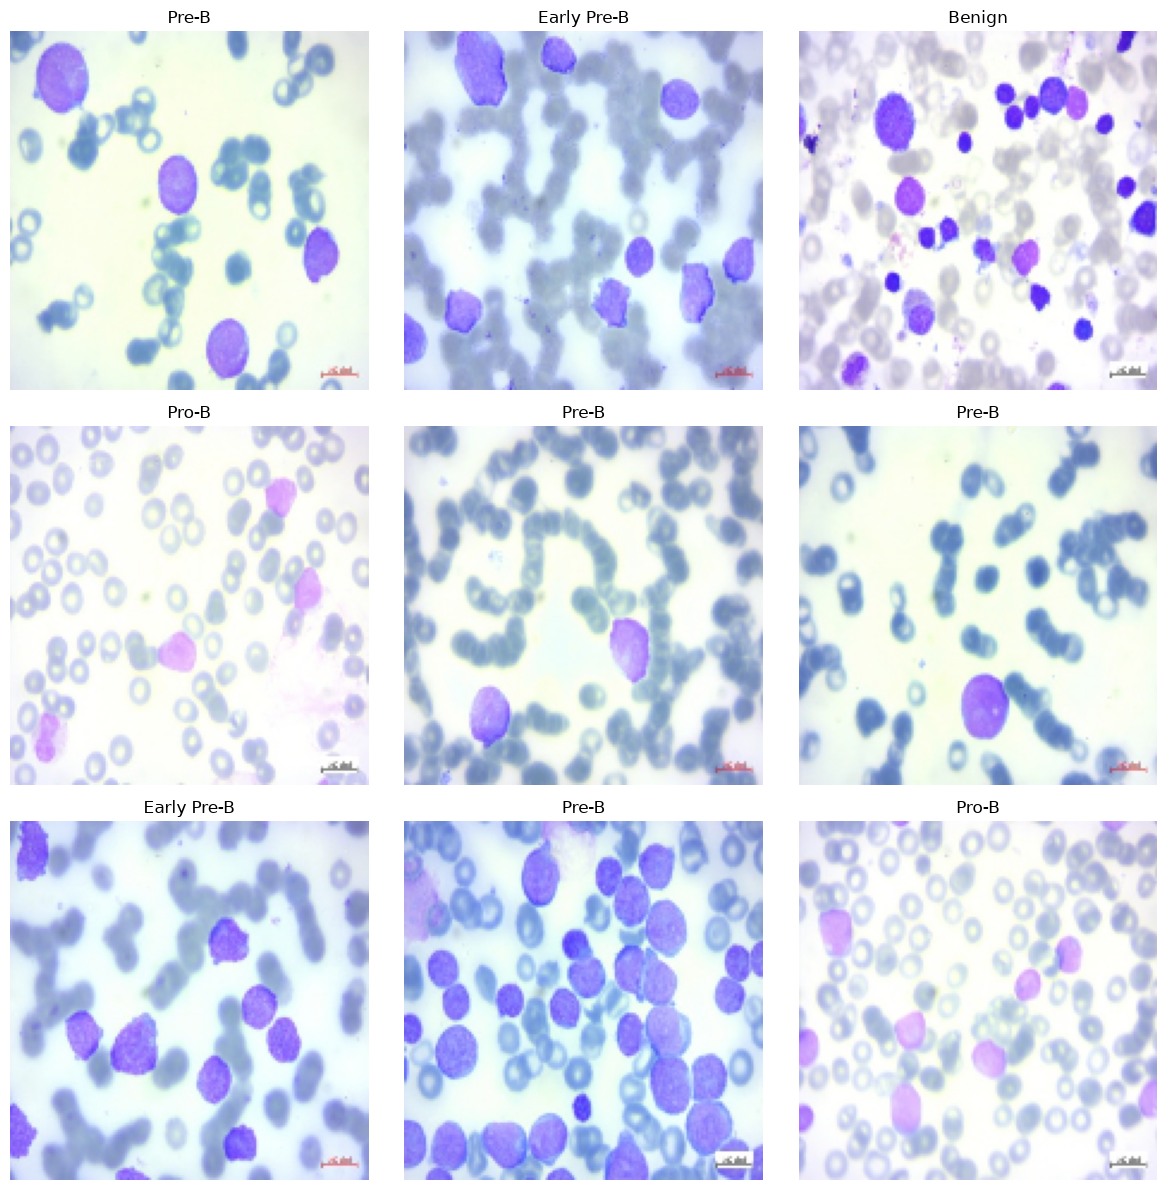

In [17]:
# preprocess_input put these in [-1, 1], so undo it before plotting.
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow((X[i] + 1) / 2)
    plt.title(CLASSES[np.argmax(y[i])])
    plt.axis('off')
plt.tight_layout()

In [25]:
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(150, 150, 3))
base = base_model(inputs, training=False)
vectors = keras.layers.GlobalAveragePooling2D()(base)
outputs = keras.layers.Dense(4)(vectors)
model = keras.Model(inputs, outputs)

In [26]:
learning_rate = 0.015
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [27]:
history = model.fit(train_ds, epochs=15, validation_data=val_ds)

Epoch 1/15


E0000 00:00:1789403678.473216  609424 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789403682.280161  609424 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8616 - loss: 0.4221

E0000 00:00:1789403700.459177  609422 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.8616 - loss: 0.4221 - val_accuracy: 0.9275 - val_loss: 0.2074
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9603 - loss: 0.1160 - val_accuracy: 0.9734 - val_loss: 0.0903
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9782 - loss: 0.0625 - val_accuracy: 0.9662 - val_loss: 0.0861
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9855 - loss: 0.0423 - val_accuracy: 0.9662 - val_loss: 0.0824
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9940 - loss: 0.0284 - val_accuracy: 0.9807 - val_loss: 0.0688
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9932 - loss: 0.0227 - val_accuracy: 0.9734 - val_loss: 0.0729
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9910 - loss: 0.0283 - val_accuracy: 0.9662 - val_loss: 0.0841
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9949 - loss: 0.0166 - val_accuracy: 0.9734 - val_loss: 

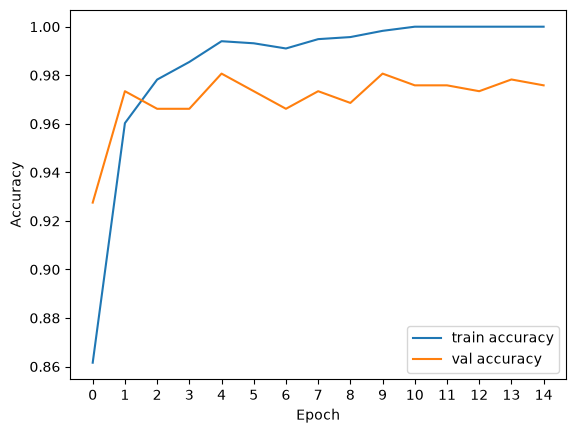

In [28]:
plt.plot(history.history['accuracy'],label = 'train accuracy')
plt.plot(history.history['val_accuracy'],label = 'val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(np.arange(0, 15, 1))
plt.legend()

# Adjusting the Learning Rate

In [29]:
def make_model(learning_rate = 0.019):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(4)(vectors)
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
    return model

In [30]:
scores = {}
for lr in [0.0001, 0.001, 0.01, 0.1, 0.002,0.021,0.03]:
    print(lr)
    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()


0.0001
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.4263 - loss: 1.3493 - val_accuracy: 0.5918 - val_loss: 1.1514
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.7091 - loss: 1.0281 - val_accuracy: 0.7488 - val_loss: 0.9258
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.7881 - loss: 0.8397 - val_accuracy: 0.8164 - val_loss: 0.7719
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8232 - loss: 0.7111 - val_accuracy: 0.8454 - val_loss: 0.6663
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8475 - loss: 0.6213 - val_accuracy: 0.8768 - val_loss: 0.5897
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8710 - loss: 0.5544 - val_accuracy: 0.8961 - val_loss: 0.5297
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8817 - loss: 0.5021 - val_accuracy: 0.8986 - val_loss: 0.4819
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8936 - loss: 0.4610 - val_accuracy: 0

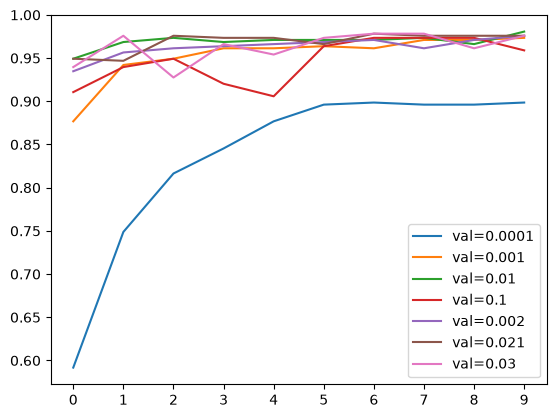

In [31]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % lr))

plt.xticks(np.arange(10))
plt.legend()

In [32]:
learning_rate = max(scores, key=lambda lr: max(scores[lr]['val_accuracy']))
print('best learning_rate =', learning_rate)

best learning_rate = 0.01


# Checkpointing

In [33]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'Blood_cell_xception_v1_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [34]:
model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.8654 - loss: 0.3788 - val_accuracy: 0.9686 - val_loss: 0.1121
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9663 - loss: 0.1015 - val_accuracy: 0.9589 - val_loss: 0.1067
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9748 - loss: 0.0764 - val_accuracy: 0.9638 - val_loss: 0.1036
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9799 - loss: 0.0580 - val_accuracy: 0.9758 - val_loss: 0.0820
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9893 - loss: 0.0410 - val_accuracy: 0.9758 - val_loss: 0.0679
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9927 - loss: 0.0294 - val_accuracy: 0.9662 - val_loss: 0.0860
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9966 - loss: 0.0247 - val_accuracy: 0.9686 - val_loss: 0.0911
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9919 - loss: 0.0250 - val_accuracy: 0.9638 -

# Adding more layers

In [14]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    outputs = keras.layers.Dense(4)(inner)
    model = keras.Model(inputs, outputs)

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [36]:
scores = {}

for size in [10,50,150, 100,200, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - accuracy: 0.7886 - loss: 0.5219 - val_accuracy: 0.9517 - val_loss: 0.1678
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9513 - loss: 0.1457 - val_accuracy: 0.9589 - val_loss: 0.1200
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9705 - loss: 0.0846 - val_accuracy: 0.9589 - val_loss: 0.1101
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9808 - loss: 0.0596 - val_accuracy: 0.9734 - val_loss: 0.0795
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9859 - loss: 0.0429 - val_accuracy: 0.9783 - val_loss: 0.0619
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9927 - loss: 0.0259 - val_accuracy: 0.9734 - val_loss: 0.0662
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9949 - loss: 0.0204 - val_accuracy: 0.9734 - val_loss: 0.0686
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9919 - loss: 0.0205 - val_accuracy: 0.966

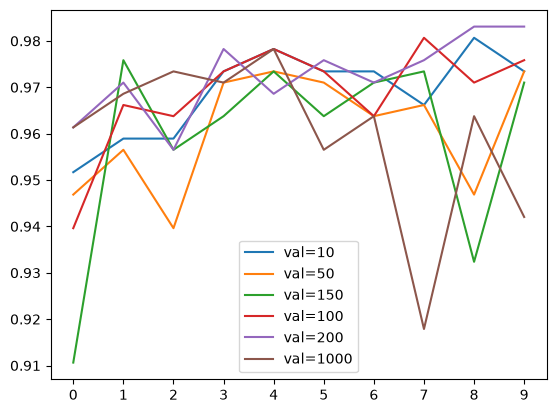

In [37]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % size))

plt.xticks(np.arange(10))
plt.legend()

In [38]:
size = max(scores, key=lambda s: max(scores[s]['val_accuracy']))
print('best size_inner =', size)

best size_inner = 200


In [39]:
size

200

# Regularization and Dropout

In [43]:
learning_rate, size

(0.01, 200)

In [44]:
def make_model(learning_rate=0.01, size_inner=200, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    outputs = keras.layers.Dense(4)(drop)
    model = keras.Model(inputs, outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [45]:
scores = {}

for droprate in [0.0,0.1,0.2,0.4,0.5,0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate,
        size_inner=size,
        droprate=droprate
    )

    history = model.fit(train_ds, epochs=15, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.8150 - loss: 0.7174 - val_accuracy: 0.9614 - val_loss: 0.1398
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9470 - loss: 0.1361 - val_accuracy: 0.9638 - val_loss: 0.0924
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9705 - loss: 0.0745 - val_accuracy: 0.9493 - val_loss: 0.1326
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9804 - loss: 0.0549 - val_accuracy: 0.9686 - val_loss: 0.0685
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9923 - loss: 0.0265 - val_accuracy: 0.9807 - val_loss: 0.0575
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9940 - loss: 0.0234 - val_accuracy: 0.9565 - val_loss: 0.1275
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9953 - loss: 0.0132 - val_accuracy: 0.9710 - val_loss: 0.0975
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9957 - loss: 0.0121 - val_accuracy: 0.97

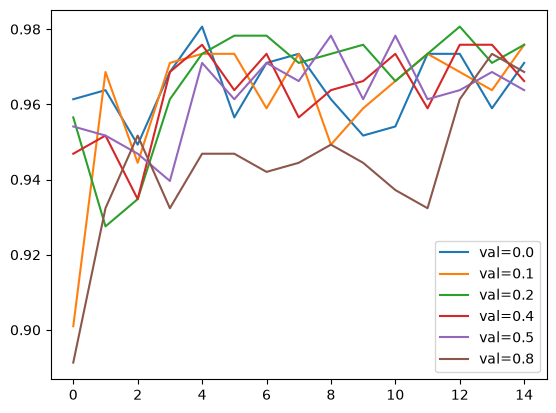

In [46]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

plt.legend()

In [47]:
droprate = max(scores, key=lambda d: max(scores[d]['val_accuracy']))
print('best droprate =', droprate)

best droprate = 0.0


In [48]:
print(f"best learning_rate={learning_rate}, size_inner={size}, droprate={droprate}")

best learning_rate=0.01, size_inner=200, droprate=0.0


# DATA AUGMENTATION

In [49]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    './data/split/train',
    target_size=(150, 150),
    batch_size=32
)

Found 2341 images belonging to 4 classes.


In [50]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './data/split/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 414 images belonging to 4 classes.


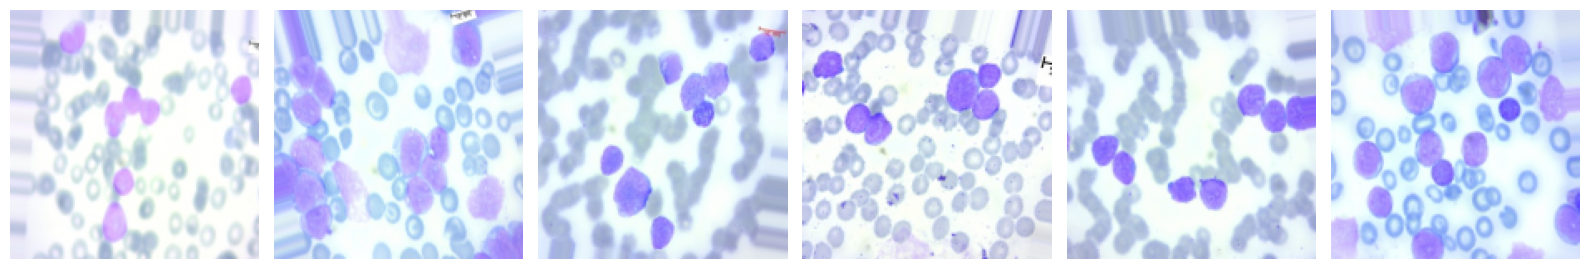

In [52]:
# Augmentation that destroys the signal is worse than none. Look at it first.
Xa, _ = next(train_ds)

plt.figure(figsize=(16, 3))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow((Xa[i] + 1) / 2)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [58]:
model = make_model(
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

hist = model.fit(train_ds, epochs=30, validation_data=val_ds)

Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.7762 - loss: 0.8643 - val_accuracy: 0.9324 - val_loss: 0.1941
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9184 - loss: 0.2276 - val_accuracy: 0.9686 - val_loss: 0.1145
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.9308 - loss: 0.1902 - val_accuracy: 0.9589 - val_loss: 0.1174
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9423 - loss: 0.1640 - val_accuracy: 0.9541 - val_loss: 0.1269
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9457 - loss: 0.1569 - val_accuracy: 0.9565 - val_loss: 0.0968
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.9445 - loss: 0.1625 - val_accuracy: 0.8961 - val_loss: 0.3132
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9475 - loss: 0.1516 - val_accuracy: 0.9469 - val_loss: 0.1507
Epoch 8/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.9539 - loss: 0.1264 - val_accuracy: 0.9589 -

In [60]:
# hist = history.history
# plt.plot(hist['val_accuracy'], label='val')
# plt.plot(hist['accuracy'], label='train')

# plt.legend()

# Training a larger model

In [24]:
def make_model(input_size=150, learning_rate=0.01, size_inner=200,
               droprate=0.0):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )
    base_model.trainable = False
    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)
    outputs = keras.layers.Dense(4)(drop)
    model = keras.Model(inputs, outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [16]:
input_size = 299

In [17]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    './data/split/train',
    target_size=(input_size, input_size),
    batch_size=32
)


val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './data/split/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 2341 images belonging to 4 classes.
Found 414 images belonging to 4 classes.


In [13]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'Cell_xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [37]:
learning_rate = 0.01
size = 200
droprate = 0.2

In [16]:

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=20, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/20


E0000 00:00:1789438400.616006  680312 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438413.887906  680312 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438417.155315  680312 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438421.355396  680312 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438422.180254  680312 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


68/74 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - accuracy: 0.7973 - loss: 0.7479

E0000 00:00:1789438444.640437  680313 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438446.168125  680313 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.8061 - loss: 0.7074

E0000 00:00:1789438457.168965  680313 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438463.262733  680313 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438479.792692  680313 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438480.576144  680313 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789438483.405579  680313 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 94s 824ms/step - accuracy: 0.8061 - loss: 0.7074 - val_accuracy: 0.9589 - val_loss: 0.1257
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 313ms/step - accuracy: 0.9457 - loss: 0.1567 - val_accuracy: 0.9710 - val_loss: 0.0754
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 300ms/step - accuracy: 0.9453 - loss: 0.1453 - val_accuracy: 0.9807 - val_loss: 0.0585
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 300ms/step - accuracy: 0.9675 - loss: 0.0947 - val_accuracy: 0.9686 - val_loss: 0.0992
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 320ms/step - accuracy: 0.9564 - loss: 0.1146 - val_accuracy: 0.9783 - val_loss: 0.0516
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 293ms/step - accuracy: 0.9616 - loss: 0.0900 - val_accuracy: 0.9758 - val_loss: 0.0748
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 315ms/step - accuracy: 0.9663 - loss: 0.0893 - val_accuracy: 0.9686 - val_loss: 0.0977
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 301ms/step - accuracy: 0.9782 - loss: 0.0663 - val_accuracy: 0.983

# Using the model

In [17]:
#load the model
#evaluate the model
#get the predictions

In [18]:
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    './data/split/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)

Found 487 images belonging to 4 classes.


In [19]:
import glob #to load the model
best_file = max(glob.glob('Cell_xception_v4_1_*.keras'),
                key=lambda f: float(f[:-len('.keras')].split('_')[-1]))
print('loading', best_file)

model = keras.models.load_model(best_file)

loading Cell_xception_v4_1_17_0.988.keras


In [13]:
model.evaluate(test_ds)

E0000 00:00:1789474790.485461  262254 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789474794.520032  262254 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789474800.640922  262254 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789474801.216057  262254 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789474801.990609  262254 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9688 - loss: 0.0674

E0000 00:00:1789474811.345680  262256 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789474812.234481  262256 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 656ms/step - accuracy: 0.9692 - loss: 0.0666


[0.06657388061285019, 0.9691991806030273]

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
CLASSES = ['Benign', 'Early Pre-B', 'Pre-B', 'Pro-B']

test_ds.reset()
pred = model.predict(test_ds, verbose=1)

y_pred = pred.argmax(axis=1)
y_true = test_ds.classes

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 294ms/step
              precision    recall  f1-score   support

      Benign      0.901     0.948     0.924        77
 Early Pre-B      0.959     0.946     0.952       147
       Pre-B      1.000     0.979     0.989       143
       Pro-B      0.992     1.000     0.996       120

    accuracy                          0.969       487
   macro avg      0.963     0.968     0.965       487
weighted avg      0.970     0.969     0.969       487



Text(0.5, 1.0, 'confusion matrix (rows sum to 1, so the diagonal is recall)')

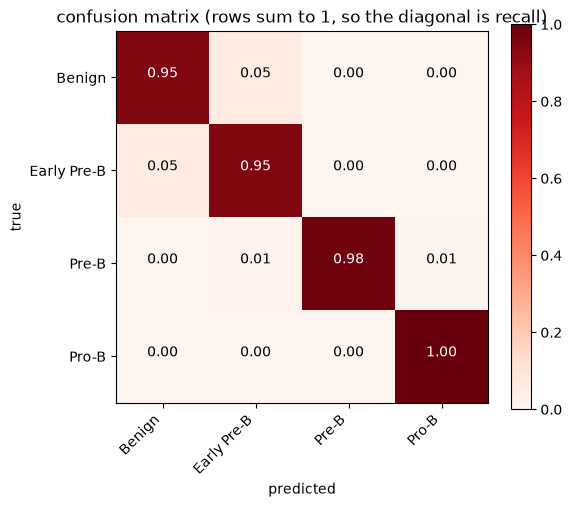

In [16]:
cm = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Reds')
ax.set_xticks(range(4), CLASSES, rotation=45, ha='right')
ax.set_yticks(range(4), CLASSES)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm[i, j]:.2f}', ha='center',
                color='white' if cm[i, j] > 0.5 else 'black')
plt.colorbar(im)
plt.title('confusion matrix (rows sum to 1, so the diagonal is recall)')

In [17]:
image_path = sorted(Path('./data/split/test/Pro-B').glob('*.jpg'))[4]
image_path

PosixPath('data/split/test/Pro-B/00029.jpg')

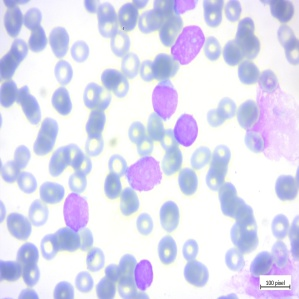

In [18]:
img = load_img(image_path, target_size=(299, 299))
img

In [19]:
x = np.array(img)
X = np.array([x])
X.shape

(1, 299, 299, 3)

In [20]:
x

array([[[222, 223, 243],
        [221, 222, 243],
        [213, 213, 237],
        ...,
        [231, 222, 243],
        [231, 221, 245],
        [231, 221, 245]],

       [[221, 222, 242],
        [223, 224, 244],
        [218, 218, 242],
        ...,
        [230, 221, 242],
        [230, 220, 244],
        [230, 221, 242]],

       [[222, 221, 239],
        [225, 223, 244],
        [221, 221, 245],
        ...,
        [232, 223, 242],
        [231, 222, 243],
        [231, 222, 243]],

       ...,

       [[231, 229, 251],
        [236, 232, 255],
        [235, 229, 255],
        ...,
        [238, 224, 255],
        [230, 215, 255],
        [218, 200, 248]],

       [[232, 230, 254],
        [234, 230, 255],
        [231, 224, 255],
        ...,
        [239, 229, 255],
        [235, 221, 255],
        [223, 206, 250]],

       [[223, 218, 248],
        [222, 217, 249],
        [217, 209, 246],
        ...,
        [244, 236, 255],
        [241, 231, 255],
        [231, 220, 254]]

In [21]:
X = preprocess_input(X)

In [22]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [23]:
dict(zip(CLASSES, pred[0]))

{'Benign': np.float32(-7.1295314),
 'Early Pre-B': np.float32(-6.5868845),
 'Pre-B': np.float32(-2.6695242),
 'Pro-B': np.float32(6.7302527)}

# Training the model on corners

corner patches: (2341, 64, 64, 3)


Text(0.5, 0.98, 'what the model will be trained on')

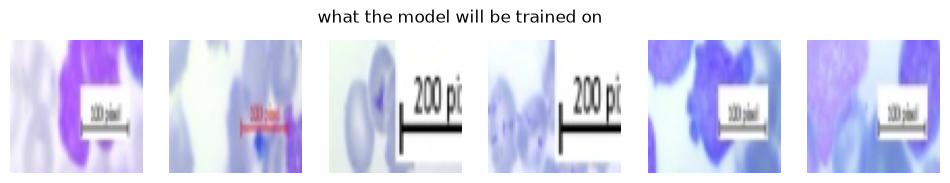

In [20]:
def load_corner(split):
    """Crop the bottom-right corner out of every image in a split."""
    X, y = [], []
    for ci, cls in enumerate(CLASSES):
        for f in sorted(Path(f'./data/split/{split}/{cls}').glob('*.jpg')):
            img = cv2.imread(str(f))
            h, w = img.shape[:2]
            X.append(cv2.resize(img[int(h * 0.88):, int(w * 0.72):], (64, 64)))
            y.append(ci)
    return np.array(X, np.float32) / 255.0, keras.utils.to_categorical(y, 4)


X_corner, y_corner = load_corner('train')
X_corner_val, y_corner_val = load_corner('validation')
X_corner_test, y_corner_test = load_corner('test')

print('corner patches:', X_corner.shape)
plt.figure(figsize=(12, 2))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(X_corner[i * 300][:, :, ::-1])   # cv2 gives BGR
    plt.axis('off')
plt.suptitle('what the model will be trained on')

If a model trained only on the tiny bottom-right corner gets 95%+ accuracy classifying "cats vs. dogs", it proves the dataset is biased—for instance, maybe all cat photos came from a website with a specific watermark in that corner, while dog photos did not.

# A BASE MODEL TO EXAMINE WHETHER THE CORNER LEAKS THE DATA

In [21]:
corner_model = keras.Sequential([
    keras.Input((64, 64, 3)),
    keras.layers.Conv2D(16, 3, activation='relu'), keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(32, 3, activation='relu'), keras.layers.MaxPooling2D(2),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(4, activation='softmax'),
])
corner_model.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])

corner_model.fit(X_corner, y_corner, epochs=15, batch_size=32, verbose=0,
                 validation_data=(X_corner_val, y_corner_val))

corner_test = corner_model.evaluate(X_corner_test, y_corner_test, verbose=0)[1]
majority = y_corner_test.sum(axis=0).max() / len(y_corner_test)
#majority: The "dumb baseline" accuracy. If you ignored the images entirely and just always guessed whichever /n 
#class appeared most often in the test set, this is the score you would get.

print(f'corner-only test accuracy : {corner_test:.3f}')
print(f'always-guess-biggest-class: {majority:.3f}')
print(f'random                    : 0.250')

corner-only test accuracy : 0.760
always-guess-biggest-class: 0.302
random                    : 0.250


(np.float64(-0.5), np.float64(298.5), np.float64(298.5), np.float64(-0.5))

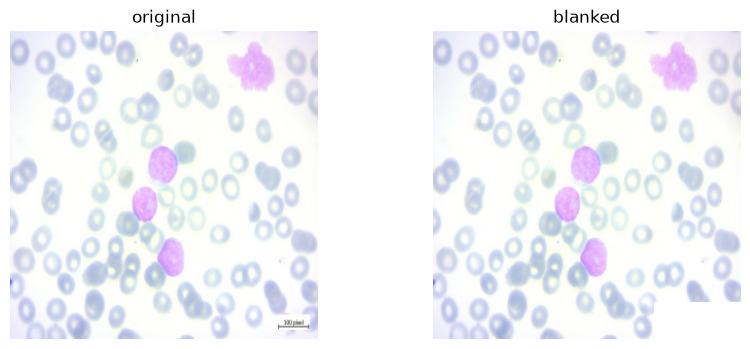

In [22]:
def blank_corner(img):
    out = img.copy()
    h, w = out.shape[:2]
    out[int(h * 0.88):, int(w * 0.72):] = 255      # white, like the box behind the bar
    return out


# Build a second copy of the split with the corner painted out.
for split in ['train', 'validation', 'test']:
    for cls in CLASSES:
        dst = Path(f'./data/split_blanked/{split}/{cls}')
        dst.mkdir(parents=True, exist_ok=True)
        for f in sorted(Path(f'./data/split/{split}/{cls}').glob('*.jpg')):
            out = dst / f.name
            if not out.exists():
                cv2.imwrite(str(out), blank_corner(cv2.imread(str(f))))

f = sorted(Path('./data/split/test/Pro-B').glob('*.jpg'))[0]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cv2.imread(str(f))[:, :, ::-1]); ax[0].set_title('original'); ax[0].axis('off')
ax[1].imshow(blank_corner(cv2.imread(str(f)))[:, :, ::-1]); ax[1].set_title('blanked'); ax[1].axis('off')

In [23]:
input_size = 299
learning_rate = 0.01
size = 200
droprate = 0.0

In [25]:
# Retrain on the blanked images, this time WITH augmentation, and save the best epoch.
# The generator is rebuilt here on purpose: reusing train_gen from an earlier cell
# depends on which cell ran last, and last time that was the one without augmentation.
blank_train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)
blank_eval_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

blank_train = blank_train_gen.flow_from_directory('./data/split_blanked/train',
    target_size=(input_size, input_size), batch_size=32)
blank_val = blank_eval_gen.flow_from_directory('./data/split_blanked/validation',
    target_size=(input_size, input_size), batch_size=32, shuffle=False)
blank_test = blank_eval_gen.flow_from_directory('./data/split_blanked/test',
    target_size=(input_size, input_size), batch_size=32, shuffle=False)

# save_best_only: a file is written only when val_accuracy beats every earlier epoch
blank_checkpoint = keras.callbacks.ModelCheckpoint(
    'Cell_xception_blanked_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

blank_model = make_model(input_size=input_size, learning_rate=learning_rate,
                         size_inner=size, droprate=droprate)
blank_history = blank_model.fit(blank_train, epochs=20, validation_data=blank_val,
                                callbacks=[blank_checkpoint])

Found 2341 images belonging to 4 classes.
Found 414 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Epoch 1/20


E0000 00:00:1789611008.919055   13883 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611011.682530   13883 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611025.763905   13883 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611026.599793   13883 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611032.513789   13883 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


15/74 ━━━━━━━━━━━━━━━━━━━━ 14s 247ms/step - accuracy: 0.5646 - loss: 1.7155

E0000 00:00:1789611043.349555   13883 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611044.490877   13883 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.8065 - loss: 0.6281

E0000 00:00:1789611080.483407   13885 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611081.279329   13885 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611082.225657   13885 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611085.212944   13885 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611091.577152   13885 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


74/74 ━━━━━━━━━━━━━━━━━━━━ 90s 792ms/step - accuracy: 0.8065 - loss: 0.6281 - val_accuracy: 0.9444 - val_loss: 0.1399
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 313ms/step - accuracy: 0.9500 - loss: 0.1540 - val_accuracy: 0.9589 - val_loss: 0.1163
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 291ms/step - accuracy: 0.9560 - loss: 0.1137 - val_accuracy: 0.9662 - val_loss: 0.1049
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 301ms/step - accuracy: 0.9539 - loss: 0.1149 - val_accuracy: 0.9541 - val_loss: 0.1233
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 327ms/step - accuracy: 0.9628 - loss: 0.1065 - val_accuracy: 0.9710 - val_loss: 0.0607
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 309ms/step - accuracy: 0.9722 - loss: 0.0806 - val_accuracy: 0.9855 - val_loss: 0.0472
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 303ms/step - accuracy: 0.9697 - loss: 0.0915 - val_accuracy: 0.9710 - val_loss: 0.0933
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 305ms/step - accuracy: 0.9658 - loss: 0.0905 - val_accuracy: 0.968

In [26]:
# The model in memory holds the LAST epoch. Load the best one from disk instead.
import glob
best_blank_file = max(glob.glob('Cell_xception_blanked_*.keras'),
                      key=lambda f: float(f[:-len('.keras')].split('_')[-1]))
print('loading', best_blank_file)

best_blank_model = keras.models.load_model(best_blank_file)
print('blanked test accuracy:', round(best_blank_model.evaluate(blank_test, verbose=0)[1], 4))

loading Cell_xception_blanked_06_0.986.keras


E0000 00:00:1789611527.343857   13886 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1789611530.822161   13886 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


blanked test accuracy: 0.9733


In [28]:
# Rebuild from the originals rather than the 299x299 squares, to avoid resizing twice.
# Same train/val/test frames as section 4, so nothing leaks across the split.
from tqdm.auto import tqdm

for split, d in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    di = Path(f'./data/seg/{split}/images/all')      # flow_from_directory wants a
    dm = Path(f'./data/seg/{split}/masks/all')       # class folder, so: 'all'
    di.mkdir(parents=True, exist_ok=True)
    dm.mkdir(parents=True, exist_ok=True)

    for i, f in enumerate(tqdm(list(d['filename']), desc=split)):
        name = f'{i:05d}.png'
        if (di / name).exists():
            continue
        bgr = cv2.resize(blank_corner(cv2.imread(f)), SEG_SIZE[::-1],
                         interpolation=cv2.INTER_AREA)
        cv2.imwrite(str(di / name), bgr)
        cv2.imwrite(str(dm / name), make_mask(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)))

for split in ['train', 'validation', 'test']:
    print(split, sum(1 for _ in Path(f'./data/seg/{split}/images').rglob('*.png')))

test: 100%|██████████| 487/487 [00:00<00:00, 154381.83it/s]

train 2341
validation 414
test 487


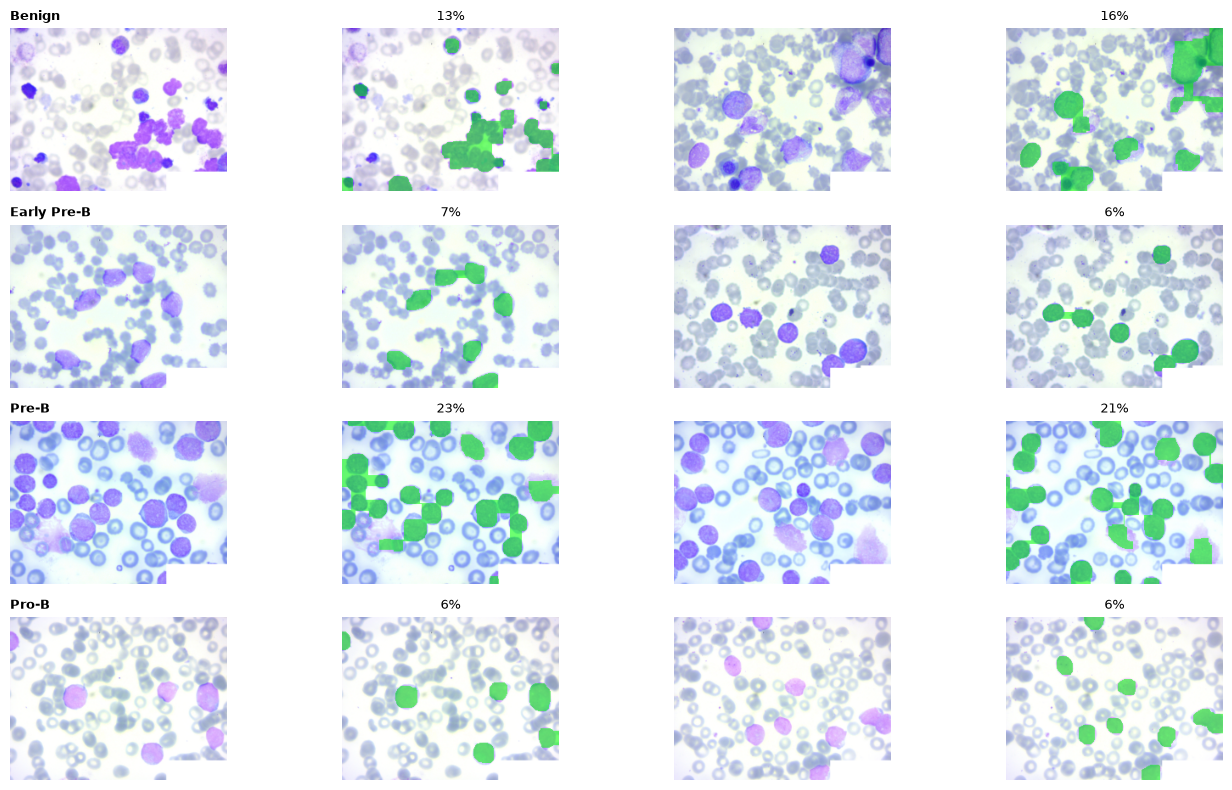

In [29]:
# Never train on pseudo-labels you have not looked at.
plt.figure(figsize=(14, 8))
for r, cls in enumerate(CLASSES):
    files = [f'{i:05d}.png' for i in np.where(train_df['label'].values == cls)[0][:2]]
    for j, name in enumerate(files):
        img = cv2.imread(f'./data/seg/train/images/all/{name}')[:, :, ::-1]
        m = cv2.imread(f'./data/seg/train/masks/all/{name}', 0)
        ov = img.copy()
        ov[m > 0] = (0.45 * ov[m > 0] + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
        plt.subplot(4, 4, r * 4 + j * 2 + 1); plt.imshow(img); plt.axis('off')
        plt.subplot(4, 4, r * 4 + j * 2 + 2); plt.imshow(ov); plt.axis('off')
        plt.title(f'{(m > 0).mean() * 100:.0f}%', fontsize=9)
    # axis('off') hides ylabel, so the row label has to be a title.
    plt.subplot(4, 4, r * 4 + 1)
    plt.title(cls, loc='left', fontweight='bold', fontsize=9)
plt.tight_layout()